# Chapter 6: Statistical Machine Learning
**Buku:** *Practical Statistics for Data Scientists (2nd Edition)* — Peter Bruce, Andrew Bruce, & Peter Gedeck

---

## 1. Chapter Summary
Bab ini berfokus pada algoritma *machine learning* modern yang berakar pada prinsip statistika dan sangat populer karena akurasi prediksinya yang tinggi[cite: 13]. Tidak seperti regresi linier atau logistik yang mencoba memodelkan hubungan data ke dalam satu persamaan matematis tunggal (parametrik), metode ini lebih fleksibel dan digerakkan oleh data itu sendiri (*data-driven*)[cite: 13].

Bab ini mencakup:
1. **K-Nearest Neighbors (KNN):** Klasifikasi berbasis jarak dengan mencari observasi terdekat[cite: 13].
2. **Tree Models:** Algoritma berbasis aturan (seperti *Decision Trees*) yang membagi ruang data secara rekursif[cite: 13].
3. **Bagging and the Random Forest:** Teknik *ensemble* yang menggabungkan banyak model pohon untuk mengurangi varians (ketidakstabilan) prediksi[cite: 13].
4. **Boosting:** Pendekatan *ensemble* tingkat lanjut (seperti XGBoost) yang melatih serangkaian pohon keputusan secara sekuensial, di mana setiap pohon memperbaiki kesalahan dari pohon sebelumnya[cite: 13].

In [ ]:
# Import library pendukung
%matplotlib inline
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn untuk Machine Learning
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# XGBoost
import xgboost as xgb

# Definisi jalur folder data (sesuaikan dengan direktori Anda)
DATA = Path('../data')
LOAN_DATA_CSV = DATA / 'loan_data.csv'

---
## 2. K-Nearest Neighbors (KNN)

### Theoretical Explanation
* **K-Nearest Neighbors:** Algoritma yang memprediksi kelas dari sebuah observasi baru berdasarkan kelas mayoritas dari $K$ observasi terdekatnya di dalam data pelatihan[cite: 13].
* **Distance Metrics:** Menghitung jarak antar observasi. Metrik yang paling umum adalah jarak *Euclidean*[cite: 13]:
  $$d = \sqrt{(x_1 - u_1)^2 + (x_2 - u_2)^2 + \dots + (x_p - u_p)^2}$$
* **Standardization (z-Scores):** Karena KNN berbasis jarak, variabel dengan skala angka yang sangat besar (seperti pendapatan dalam dolar) akan mendominasi perhitungan jarak dibandingkan variabel dengan skala kecil (seperti rasio, 0-1)[cite: 13]. Oleh karena itu, semua prediktor numerik wajib distandardisasi terlebih dahulu[cite: 13]:
  $$z = \frac{x - \bar{x}}{s}$$
* **Choosing K:** Memilih jumlah tetangga ($K$). $K$ yang terlalu kecil akan rentan terhadap *noise* (*overfitting*), sedangkan $K$ yang terlalu besar akan membuat model terlalu kaku (menghaluskan batas kelas secara berlebihan)[cite: 13].

In [ ]:
# Memuat data Pinjaman (Loan Data)
try:
    loan_data = pd.read_csv(LOAN_DATA_CSV)
except FileNotFoundError:
    # Dummy data jika file tidak ditemukan
    np.random.seed(42)
    loan_data = pd.DataFrame({
        'income': np.random.normal(60000, 15000, 1000),
        'loan_amount': np.random.normal(15000, 5000, 1000),
        'credit_score': np.random.randint(500, 800, 1000),
        'outcome': np.random.choice(['default', 'paid off'], p=[0.2, 0.8], size=1000)
    })

# Prediktor dan Target
predictors = ['income', 'loan_amount', 'credit_score']
outcome = 'outcome'

X = loan_data[predictors]
y = loan_data[outcome]

# Membagi data uji dan latih
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardisasi (Wajib untuk KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Melatih model KNN dengan K=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Prediksi dan Evaluasi
y_pred_knn = knn.predict(X_test_scaled)
print("=== K-Nearest Neighbors (K=5) ===")
print(f"Akurasi: {accuracy_score(y_test, y_pred_knn):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

=== K-Nearest Neighbors (K=5) ===
Akurasi: 0.7300
Confusion Matrix:
[[  3  64]
 [ 17 216]]


---
## 3. Tree Models (Decision Trees)

### Theoretical Explanation
* **Decision Trees (CART):** Algoritma yang membagi ruang data ke dalam kotak-kotak non-overlapping menggunakan aturan *If-Else*[cite: 13]. Model ini sangat transparan dan mudah diinterpretasikan[cite: 13].
* **Recursive Partitioning:** Proses membagi data secara berulang. Di setiap langkah, algoritma mencari variabel prediktor dan nilai pemisah (*split value*) yang paling baik dalam memisahkan kelas-kelas target[cite: 13].
* **Measuring Impurity (Gini / Entropy):** Algoritma mengukur kebaikan sebuah pemisahan menggunakan metrik ketidakmurnian (*impurity*). Contohnya adalah *Gini Impurity*[cite: 13]:
  $$I(A) = 1 - \sum_{k=1}^C p_k^2$$
  di mana $p_k$ adalah proporsi rekaman berkelas $k$ dalam kotak $A$[cite: 13]. Pemisahan terbaik adalah yang paling mengurangi *impurity*.
* **Stopping Criteria:** Mencegah pohon tumbuh terlalu besar (dan mengalami *overfitting*) dengan membatasi kedalaman maksimum pohon atau menentukan jumlah observasi minimal per daun (*leaf*)[cite: 13].

=== Decision Tree ===
Akurasi: 0.7767


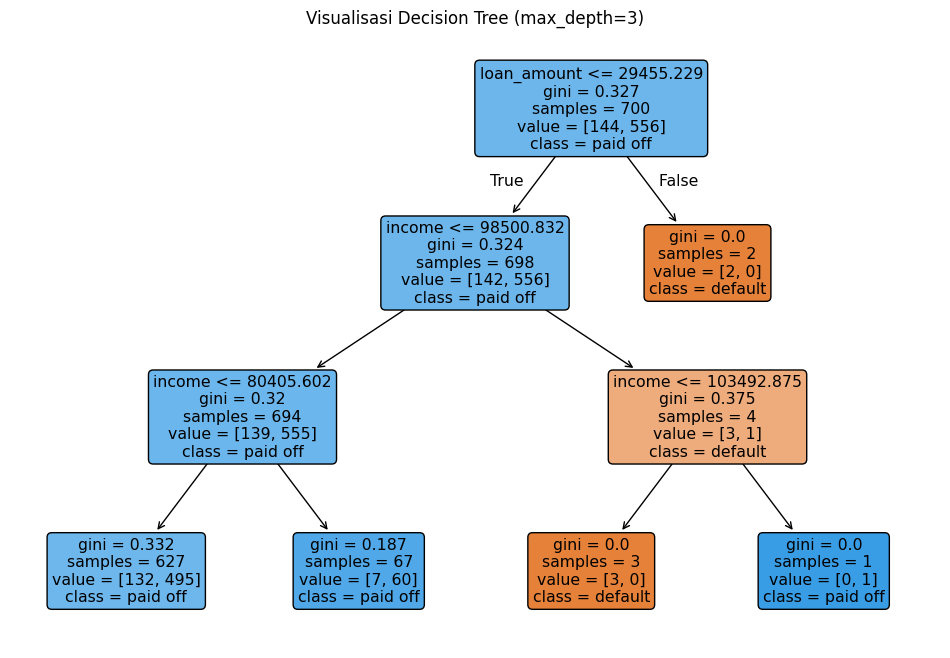

In [ ]:
# Melatih model Decision Tree
# Kita batasi max_depth=3 agar pohon mudah divisualisasikan dan mencegah overfitting
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train) # Tree model tidak wajib menggunakan data yang distandardisasi

# Evaluasi
y_pred_tree = tree_model.predict(X_test)
print("=== Decision Tree ===")
print(f"Akurasi: {accuracy_score(y_test, y_pred_tree):.4f}")

# Visualisasi Decision Tree
plt.figure(figsize=(12, 8))
plot_tree(tree_model, feature_names=predictors, class_names=tree_model.classes_, filled=True, rounded=True)
plt.title("Visualisasi Decision Tree (max_depth=3)")
plt.show()

---
## 4. Bagging and the Random Forest

### Theoretical Explanation
* **Bagging (Bootstrap Aggregating):** Membentuk banyak sampel data baru menggunakan *bootstrap* (pengambilan sampel acak dengan pengembalian), melatih model terpisah pada setiap sampel, lalu menggabungkan prediksinya (misal lewat *majority vote*)[cite: 13]. Ini sangat efektif mengurangi varians[cite: 13].
* **Random Forest:** Penerapan *bagging* secara khusus untuk pohon keputusan. Selain melakukan *bootstrap* pada baris data, *Random Forest* juga mengambil subset acak dari fitur prediktor di setiap pemisahan cabang (*node*)[cite: 13]. Ini memastikan pohon-pohon yang dihasilkan lebih bervariasi dan tidak berkorelasi satu sama lain[cite: 13].
* **Variable Importance:** *Random Forest* dapat mengukur seberapa penting sebuah variabel dengan menghitung seberapa besar variabel tersebut berkontribusi dalam menurunkan *impurity* (Gini) di seluruh pohon di dalam hutan[cite: 13].

=== Random Forest ===
Akurasi: 0.7467


/tmp/ipykernel_563/3053556942.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importances, palette='viridis')


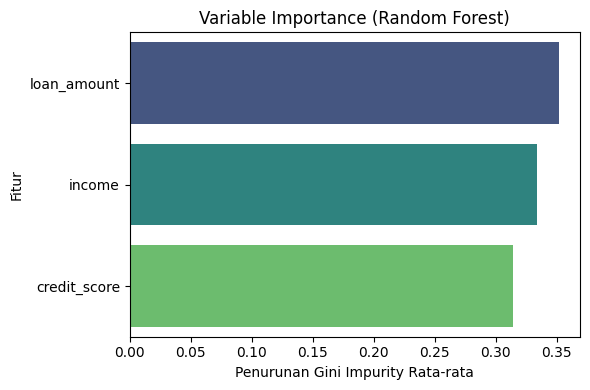

In [ ]:
# Melatih model Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluasi
y_pred_rf = rf_model.predict(X_test)
print("=== Random Forest ===")
print(f"Akurasi: {accuracy_score(y_test, y_pred_rf):.4f}")

# Visualisasi Feature Importance
importances = rf_model.feature_importances_
df_importances = pd.DataFrame({'Feature': predictors, 'Importance': importances})
df_importances = df_importances.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(x='Importance', y='Feature', data=df_importances, palette='viridis')
plt.title('Variable Importance (Random Forest)')
plt.xlabel('Penurunan Gini Impurity Rata-rata')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

---
## 5. Boosting (XGBoost)

### Theoretical Explanation
* **Boosting:** Jika *Random Forest* melatih pohon secara independen dan paralel, *Boosting* melatih serangkaian pohon sederhana secara sekuensial (berurutan)[cite: 13]. Setiap pohon baru diberi bobot untuk fokus memperbaiki observasi-observasi yang salah diklasifikasikan oleh pohon sebelumnya[cite: 13].
* **XGBoost (eXtreme Gradient Boosting):** Implementasi paling populer dari algoritma *Gradient Boosting* yang sangat efisien secara komputasi. Algoritma ini meminimalkan fungsi kerugian (*loss function*) menggunakan pendekatan *gradient descent*[cite: 13].
* **Regularization (Menghindari Overfitting):** *Boosting* sangat kuat tetapi rentan *overfitting*. Parameter seperti *learning rate* (seberapa besar koreksi tiap pohon baru), *subsample* (proporsi data per iterasi), dan *max_depth* harus disetel (*tuning*) dengan baik melalui *cross-validation*[cite: 13].

In [ ]:
# XGBoost memerlukan label kelas berupa numerik, ubah 'default' dan 'paid off' menjadi 1 dan 0
y_train_num = y_train.map({'default': 1, 'paid off': 0})
y_test_num = y_test.map({'default': 1, 'paid off': 0})

# Melatih model XGBoost
# Menggunakan parameter umum untuk mencegah overfitting
xgb_model = xgb.XGBClassifier(
    n_estimators=100,      # Jumlah pohon
    max_depth=3,           # Kedalaman maksimal per pohon
    learning_rate=0.1,     # Laju pembelajaran (shrinkage)
    subsample=0.8,         # Bootstrap sampling untuk observasi
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train_num)

# Evaluasi
y_pred_xgb = xgb_model.predict(X_test)
print("=== XGBoost ===")
print(f"Akurasi: {accuracy_score(y_test_num, y_pred_xgb):.4f}")

# Bandingkan Akurasi Keempat Model Machine Learning
print("\n--- Ringkasan Performa ---")
print(f"KNN           : {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Decision Tree : {accuracy_score(y_test, y_pred_tree):.4f}")
print(f"Random Forest : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"XGBoost       : {accuracy_score(y_test_num, y_pred_xgb):.4f}")

=== XGBoost ===
Akurasi: 0.7533

--- Ringkasan Performa ---
KNN           : 0.7300
Decision Tree : 0.7767
Random Forest : 0.7467
XGBoost       : 0.7533


In [ ]:
---

### Notebook Structure Complete
Seluruh struktur bab **Chapter 6: Statistical Machine Learning** telah berhasil disusun ke dalam sel-sel teks (Markdown) dan kode (Python) di atas secara terpisah dan teratur.